In [20]:
# Import required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')


In [21]:
# ============================================================================
# STEP 1: LOAD AND EXPLORE DATA
# ============================================================================
print("=" * 70)
print("STEP 1: LOAD AND EXPLORE DATA")
print("=" * 70)

# Load the data
df = pd.read_csv('wind-weather-daily.csv')

# Display basic info
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nLast 5 rows:")
print(df.tail())

# Check for missing values
print(f"\nMissing values:")
print(df.isnull().sum())

# Statistics
print(f"\nWind Speed Statistics:")
print(df['mean_wind_speed'].describe())

STEP 1: LOAD AND EXPLORE DATA

Dataset shape: (729, 3)
Columns: ['timestamp', 'mean_wind_dir', 'mean_wind_speed']

First 5 rows:
    timestamp  mean_wind_dir  mean_wind_speed
0  2001-01-01     110.833333         5.208333
1  2001-01-02     163.750000         8.000000
2  2001-01-03     202.916667         8.666667
3  2001-01-04     195.833333         5.541667
4  2001-01-05     261.250000         3.250000

Last 5 rows:
      timestamp  mean_wind_dir  mean_wind_speed
724  2002-12-27     184.166667         4.875000
725  2002-12-28     280.833333         8.708333
726  2002-12-29     128.333333         3.875000
727  2002-12-30      45.833333         4.458333
728  2002-12-31      87.916667         5.250000

Missing values:
timestamp          0
mean_wind_dir      0
mean_wind_speed    0
dtype: int64

Wind Speed Statistics:
count    729.000000
mean       6.916910
std        3.511242
min        1.125000
25%        4.458333
50%        6.041667
75%        8.708333
max       28.958333
Name: mean_wind_

In [22]:
# ============================================================================
# STEP 2: VISUALIZE THE TIME SERIES
# ============================================================================
print("\n" + "=" * 70)
print("STEP 2: VISUALIZE TIME SERIES DATA")
print("=" * 70)

# Plot the entire time series
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Full 2-year series
axes[0].plot(df.index, df['mean_wind_speed'], linewidth=0.5, color='blue')
axes[0].set_title('Full Time Series: Mean Wind Speed (2001-2002)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Wind Speed (knots)')
axes[0].grid(alpha=0.3)

# Last 3 months (zoomed in)
last_180 = df['mean_wind_speed'].tail(180 * 24)  # 180 days of hourly data
axes[1].plot(last_180.values, linewidth=1, color='green')
axes[1].set_title('Last 6 Months: Wind Speed', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Wind Speed (knots)')
axes[1].grid(alpha=0.3)

# Last 7 days (hourly detail)
last_7_days = df['mean_wind_speed'].tail(7 * 24)
axes[2].plot(last_7_days.values, marker='o', linewidth=1, markersize=3, color='red')
axes[2].set_title('Last 7 Days: Wind Speed (Hourly)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Hours')
axes[2].set_ylabel('Wind Speed (knots)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('01_time_series_exploration.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved: 01_time_series_exploration.png")
plt.close()


STEP 2: VISUALIZE TIME SERIES DATA

✓ Saved: 01_time_series_exploration.png


In [23]:
# ============================================================================
# STEP 3: CHECK STATIONARITY (ADF TEST)
# ============================================================================
print("\n" + "=" * 70)
print("STEP 3: CHECK STATIONARITY (ADF TEST)")
print("=" * 70)

# Perform Augmented Dickey-Fuller test
wind_speed = df['mean_wind_speed'].values
result = adfuller(wind_speed)

print(f"\nADF Test Results:")
print(f"  ADF Statistic: {result[0]:.6f}")
print(f"  p-value: {result[1]:.6f}")
print(f"  Critical values:")
for key, value in result[4].items():
    print(f"    {key}: {value:.3f}")

if result[1] < 0.05:
    print(f"\n  ✓ Time series IS stationary (p-value < 0.05)")
    print(f"    This is good for ARIMA!")
else:
    print(f"\n  ✗ Time series is NOT stationary (p-value >= 0.05)")
    print(f"    We'll use differencing (d=1) in ARIMA")


STEP 3: CHECK STATIONARITY (ADF TEST)

ADF Test Results:
  ADF Statistic: -9.281340
  p-value: 0.000000
  Critical values:
    1%: -3.439
    5%: -2.866
    10%: -2.569

  ✓ Time series IS stationary (p-value < 0.05)
    This is good for ARIMA!


In [24]:
# ============================================================================
# STEP 4: ANALYZE ACF AND PACF
# ============================================================================
print("\n" + "=" * 70)
print("STEP 4: ANALYZE ACF AND PACF FOR PARAMETER SELECTION")
print("=" * 70)

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# ACF plot
plot_acf(wind_speed, lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('ACF')

# PACF plot
plot_pacf(wind_speed, lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('PACF')
axes[1].set_xlabel('Lags')

plt.tight_layout()
plt.savefig('02_acf_pacf_plots.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved: 02_acf_pacf_plots.png")
print("\nInterpretation Guide:")
print("  - ACF shows how correlated points are with their past values")
print("  - PACF shows direct correlation after removing intermediate effects")
print("  - Use these to guide p and q parameters")
plt.close()


STEP 4: ANALYZE ACF AND PACF FOR PARAMETER SELECTION

✓ Saved: 02_acf_pacf_plots.png

Interpretation Guide:
  - ACF shows how correlated points are with their past values
  - PACF shows direct correlation after removing intermediate effects
  - Use these to guide p and q parameters


In [25]:
# ============================================================================
# STEP 5: AUTO ARIMA - FIND OPTIMAL PARAMETERS
# ============================================================================
print("\n" + "=" * 70)
print("STEP 5: AUTO ARIMA - FIND OPTIMAL PARAMETERS")
print("=" * 70)

print("\nSearching for optimal ARIMA parameters...")
print("(This may take a minute...)\n")

auto_model = auto_arima(
    wind_speed,
    d=0,
    seasonal=False,  # We're using univariate ARIMA, not SARIMA
    stepwise=True,   # Use stepwise algorithm for speed
    trace=True,      # Show progress
    error_action='ignore',
    suppress_warnings=True,
    max_p=4,
    max_q=4,  
)

print(f"\n{'=' * 70}")
print(f"AUTO ARIMA RESULTS")
print(f"{'=' * 70}")
print(f"\nOptimal ARIMA Order: {auto_model.order}")
print(f"\nModel Summary:")
print(auto_model.summary())

optimal_order = auto_model.order
p, d, q = optimal_order
print(f"\nParameters breakdown:")
print(f"  p={p} (Autoregressive): Uses {p} past values to predict")
print(f"  d={d} (Differencing): {d} level(s) of differencing for stationarity")
print(f"  q={q} (Moving Average): Uses {q} past errors to predict")


STEP 5: AUTO ARIMA - FIND OPTIMAL PARAMETERS

Searching for optimal ARIMA parameters...
(This may take a minute...)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=3626.159, Time=0.15 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=5057.477, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=3767.972, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=4455.923, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=3638.285, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=3624.293, Time=0.11 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=3693.271, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=3736.989, Time=0.02 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=3626.242, Time=0.15 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=3677.024, Time=0.03 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=3625.889, Time=0.28 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=3616.453, Time=0.23 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=3623.

In [26]:
# ============================================================================
# STEP 6: TRAIN/TEST SPLIT
# ============================================================================
print("\n" + "=" * 70)
print("STEP 6: TRAIN/TEST SPLIT")
print("=" * 70)

# Split: 80% train, 20% test
train_size = int(len(df) * 0.8)
train_data = df['mean_wind_speed'][:train_size]
test_data = df['mean_wind_speed'][train_size:]

print(f"\nData split:")
print(f"  Total observations: {len(df)}")
print(f"  Training set: {len(train_data)} ({len(train_data)/len(df)*100:.1f}%)")
print(f"  Test set: {len(test_data)} ({len(test_data)/len(df)*100:.1f}%)")
print(f"\n  Training period: {df['timestamp'].iloc[0]} to {df['timestamp'].iloc[train_size-1]}")
print(f"  Test period: {df['timestamp'].iloc[train_size]} to {df['timestamp'].iloc[-1]}")


STEP 6: TRAIN/TEST SPLIT

Data split:
  Total observations: 729
  Training set: 583 (80.0%)
  Test set: 146 (20.0%)

  Training period: 2001-01-01 to 2002-08-06
  Test period: 2002-08-07 to 2002-12-31


In [27]:
# ============================================================================
# STEP 7: FIT ARIMA MODEL ON TRAINING DATA
# ============================================================================
print("\n" + "=" * 70)
print("STEP 7: FIT ARIMA MODEL ON TRAINING DATA")
print("=" * 70)

print(f"\nFitting ARIMA{optimal_order} on training data...")

arima_model = ARIMA(train_data, order=optimal_order)
fitted_model = arima_model.fit()

print(f"\n✓ Model fitted successfully!")
print(f"\nModel Diagnostics:")
print(f"  AIC: {fitted_model.aic:.2f}")
print(f"  BIC: {fitted_model.bic:.2f}")
print(f"  Log-Likelihood: {fitted_model.llf:.2f}")

print(f"\nFull Model Summary:")
print(fitted_model.summary())



STEP 7: FIT ARIMA MODEL ON TRAINING DATA

Fitting ARIMA(3, 0, 0) on training data...

✓ Model fitted successfully!

Model Diagnostics:
  AIC: 2925.36
  BIC: 2947.20
  Log-Likelihood: -1457.68

Full Model Summary:
                               SARIMAX Results                                
Dep. Variable:        mean_wind_speed   No. Observations:                  583
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1457.679
Date:                Fri, 13 Mar 2026   AIC                           2925.358
Time:                        14:21:36   BIC                           2947.199
Sample:                             0   HQIC                          2933.871
                                - 583                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

In [ ]:
# ============================================================================
# STEP 8: MAKE PREDICTIONS ON TEST SET
# ============================================================================
print("\n" + "=" * 70)
print("STEP 8: MAKE PREDICTIONS ON TEST SET")
print("=" * 70)

print(f"\nGenerating rolling 1-step-ahead forecasts for {len(test_data)} days...")

# Use concat instead of df['mean_wind_speed'] — a later cell reassigns df
# to the hourly dataset which would break the index alignment.
full_series = pd.concat([train_data, test_data])
full_model = ARIMA(full_series, order=optimal_order)
full_fitted = full_model.fit()

# dynamic=False: each prediction conditions on actual past values rather
# than prior predictions — avoids the multi-step mean-convergence problem.
predictions = full_fitted.get_prediction(start=train_size, dynamic=False)
predicted_mean = predictions.predicted_mean
confidence_interval = predictions.conf_int()

print(f"✓ Rolling 1-step-ahead predictions generated!")

In [29]:
# ============================================================================
# STEP 9: EVALUATE MODEL PERFORMANCE
# ============================================================================
print("\n" + "=" * 70)
print("STEP 9: EVALUATE MODEL PERFORMANCE")
print("=" * 70)

# Calculate error metrics
mae = mean_absolute_error(test_data, predicted_mean)
rmse = np.sqrt(mean_squared_error(test_data, predicted_mean))
mape = np.mean(np.abs((test_data - predicted_mean) / test_data)) * 100

print(f"\nError Metrics on Test Set:")
print(f"  MAE (Mean Absolute Error): {mae:.4f} knots")
print(f"  RMSE (Root Mean Squared Error): {rmse:.4f} knots")
print(f"  MAPE (Mean Absolute Percentage Error): {mape:.2f}%")

# Baseline comparison (using mean of training data)
baseline_pred = train_data.mean()
baseline_mae = mean_absolute_error(test_data, [baseline_pred] * len(test_data))
baseline_rmse = np.sqrt(mean_squared_error(test_data, [baseline_pred] * len(test_data)))

print(f"\nBaseline Comparison (naive forecast = training mean):")
print(f"  Baseline MAE: {baseline_mae:.4f} knots")
print(f"  Baseline RMSE: {baseline_rmse:.4f} knots")
print(f"\nARIMA vs Baseline:")
print(f"  MAE improvement: {(baseline_mae - mae) / baseline_mae * 100:+.2f}%")
print(f"  RMSE improvement: {(baseline_rmse - rmse) / baseline_rmse * 100:+.2f}%")



STEP 9: EVALUATE MODEL PERFORMANCE

Error Metrics on Test Set:
  MAE (Mean Absolute Error): 1.8639 knots
  RMSE (Root Mean Squared Error): 2.4031 knots
  MAPE (Mean Absolute Percentage Error): 40.85%

Baseline Comparison (naive forecast = training mean):
  Baseline MAE: 2.6047 knots
  Baseline RMSE: 3.0210 knots

ARIMA vs Baseline:
  MAE improvement: +28.44%
  RMSE improvement: +20.46%


In [ ]:
# ============================================================================
# STEP 10: VISUALIZE PREDICTIONS
# ============================================================================
print("\n" + "=" * 70)
print("STEP 10: VISUALIZE PREDICTIONS vs ACTUAL")
print("=" * 70)

fig, ax = plt.subplots(figsize=(16, 5))

# Full actual series (train + test)
ax.plot(df.index[:train_size], train_data.values,
        label='Training Data', linewidth=1.5, color='steelblue')
ax.plot(df.index[train_size:], test_data.values,
        label='Actual (Test)', linewidth=1.5, color='steelblue', linestyle='--')

# Predicted values overlaid on test period only
ax.plot(predicted_mean.index, predicted_mean.values,
        label='ARIMA Forecast', linewidth=2, color='red')
ax.fill_between(confidence_interval.index,
                confidence_interval.iloc[:, 0],
                confidence_interval.iloc[:, 1],
                alpha=0.2, color='red', label='95% Confidence Interval')

# Vertical line marking train/test boundary
ax.axvline(x=train_size, color='black', linestyle=':', linewidth=1.5, label='Train/Test Split')

ax.set_title('ARIMA Forecast vs Actual Wind Speed', fontsize=13, fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('Wind Speed (knots)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('03_predictions_vs_actual.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved: 03_predictions_vs_actual.png")
plt.show()

TEST 1: Autocorrelation (is there ANY pattern?)
Lag 1 ACF: 0.8987
Lag 6 ACF: 0.5804
Lag 24 ACF: 0.3798
✓ Good: Shows some autocorrelation

TEST 2: Stationarity (ADF Test)
ADF Statistic: -11.356616
p-value: 0.000000
✓ Data is stationary (d=0 might be better)

TEST 3: Hourly Volatility
Mean hourly change: 1.43 knots
Mean wind speed: 6.92 knots
Volatility ratio: 0.21
✓ Reasonable volatility

TEST 4: Daily Seasonality (24-hour cycle)
ACF at lag 24 (daily): 0.3798
✓ Strong 24-hour pattern detected (SARIMA would help)

✓ Saved diagnostic plot: wind_diagnostics.png


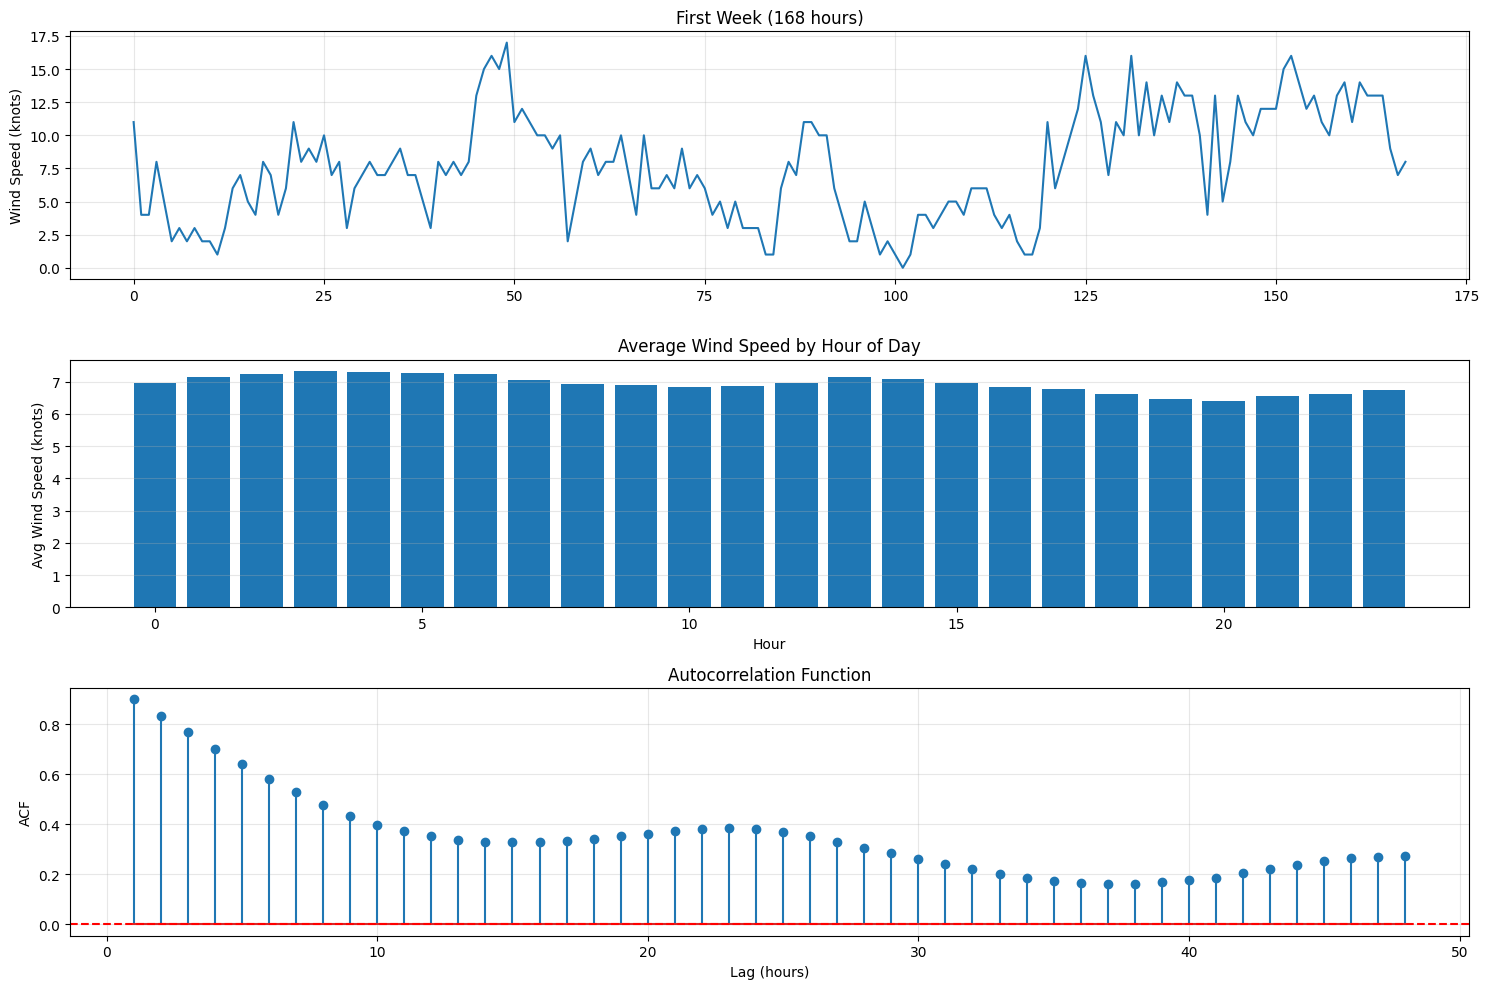

In [31]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import acf, adfuller
import matplotlib.pyplot as plt

df = pd.read_csv('wind-weather-data.csv')
wind = df['mean_wind_speed'].values

# TEST 1: Is it white noise?
print("=" * 60)
print("TEST 1: Autocorrelation (is there ANY pattern?)")
print("=" * 60)
acf_vals = acf(wind, nlags=48)
print(f"Lag 1 ACF: {acf_vals[1]:.4f}")
print(f"Lag 6 ACF: {acf_vals[6]:.4f}")
print(f"Lag 24 ACF: {acf_vals[24]:.4f}")

if abs(acf_vals[1]) < 0.1:
    print("⚠️  WARNING: Very low autocorrelation - might be mostly white noise!")
else:
    print("✓ Good: Shows some autocorrelation")

# TEST 2: Check stationarity
print("\n" + "=" * 60)
print("TEST 2: Stationarity (ADF Test)")
print("=" * 60)
result = adfuller(wind)
print(f"ADF Statistic: {result[0]:.6f}")
print(f"p-value: {result[1]:.6f}")
if result[1] < 0.05:
    print("✓ Data is stationary (d=0 might be better)")
else:
    print("⚠️  Data is non-stationary (needs differencing)")

# TEST 3: Check volatility
print("\n" + "=" * 60)
print("TEST 3: Hourly Volatility")
print("=" * 60)
hourly_changes = np.abs(np.diff(wind))
print(f"Mean hourly change: {hourly_changes.mean():.2f} knots")
print(f"Mean wind speed: {wind.mean():.2f} knots")
volatility_ratio = hourly_changes.mean() / wind.mean()
print(f"Volatility ratio: {volatility_ratio:.2f}")
if volatility_ratio > 0.3:
    print("⚠️  Very volatile! Hourly data might be too noisy")
else:
    print("✓ Reasonable volatility")

# TEST 4: Check for daily seasonality
print("\n" + "=" * 60)
print("TEST 4: Daily Seasonality (24-hour cycle)")
print("=" * 60)
acf_24 = acf_vals[24]
print(f"ACF at lag 24 (daily): {acf_24:.4f}")
if abs(acf_24) > 0.1:
    print("✓ Strong 24-hour pattern detected (SARIMA would help)")
else:
    print("⚠️  No clear daily pattern")

# TEST 5: Visualize patterns
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(wind[:7*24])  # First week
plt.title("First Week (168 hours)")
plt.ylabel("Wind Speed (knots)")
plt.grid(alpha=0.3)

plt.subplot(3, 1, 2)
# Plot by hour of day
hourly_avg = np.array([wind[i::24].mean() for i in range(24)])
plt.bar(range(24), hourly_avg)
plt.title("Average Wind Speed by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Avg Wind Speed (knots)")
plt.grid(alpha=0.3, axis='y')

plt.subplot(3, 1, 3)
plt.stem(range(1, len(acf_vals)), acf_vals[1:])
plt.title("Autocorrelation Function")
plt.xlabel("Lag (hours)")
plt.ylabel("ACF")
plt.axhline(y=0, color='r', linestyle='--')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('wind_diagnostics.png', dpi=150)
print("\n✓ Saved diagnostic plot: wind_diagnostics.png")
plt.show()